### Lab-3 : Self-Practice

#### In this week, your self-practice task will consist to analyze the impact of class imballance on the performance of the logistic regression model.

#### Class imbalance is very common in real life. For example, in a classification problem to predict whether a person has a certain very rare disease, the dataset will always contain more negative samples than positive ones. This situation can have a significant impact on the performance of the model. You will analyze this situation in the case of the Titanic dataset used in the lab.

### 1. Load the titanic dataset and <b>PLOT</b> the proportion of positive and negative samples (survived vs non survived)

In [1]:
from xml.sax.handler import feature_external_ges

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
### write your code here. Load the dataset and plot (barplot) proportion of each class 
df = pd.read_csv('titanic.csv')
df.head()

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,151.5500,S
2,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,151.5500,S
3,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,151.5500,S
4,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,151.5500,S


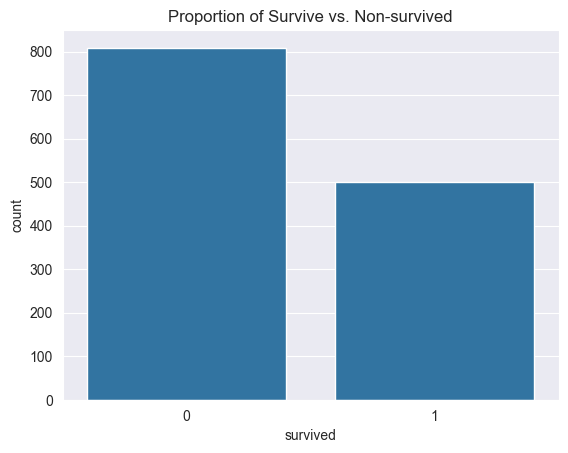

In [3]:
sns.countplot(data=df, x='survived')
plt.title("Proportion of Survive vs. Non-survived")
plt.show()

#### Preprocess the data as it has been done in the lab, feel free to adapt

In [4]:
#### preprocess the data
df.isna().sum()

survived      0
pclass        0
name          0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64

In [5]:
df['age'] = df['age'].fillna(df['age'].mean())
df.isna().sum()

survived    0
pclass      0
name        0
sex         0
age         0
sibsp       0
parch       0
fare        1
embarked    2
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  1309 non-null   int64  
 1   pclass    1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1309 non-null   float64
 5   sibsp     1309 non-null   int64  
 6   parch     1309 non-null   int64  
 7   fare      1308 non-null   float64
 8   embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 92.2+ KB


In [7]:
df[['embarked']].head(), df['embarked'].unique()

(  embarked
 0        S
 1        S
 2        S
 3        S
 4        S,
 array(['S', 'C', nan, 'Q'], dtype=object))

In [8]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False)
encoded_data = encoder.fit_transform(df[['sex']])
encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(['sex']),
    index=df.index
)

df = pd.concat([df.drop('sex', axis=1), encoded_df], axis=1)
df.head()

,survived,pclass,name,age,sibsp,parch,fare,embarked,sex_female,sex_male
0,1,1,"Allen, Miss. Elisabeth Walton",29.00,0,0,211.3375,S,1.0,0.0
1,1,1,"Allison, Master. Hudson Trevor",0.92,1,2,151.5500,S,0.0,1.0
2,0,1,"Allison, Miss. Helen Loraine",2.00,1,2,151.5500,S,1.0,0.0
3,0,1,"Allison, Mr. Hudson Joshua Creighton",30.00,1,2,151.5500,S,0.0,1.0
4,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.00,1,2,151.5500,S,1.0,0.0


In [9]:
encoded_data_embarked = encoder.fit_transform(df[['embarked']])

embarked_df = pd.DataFrame(
    encoded_data_embarked,
    columns=encoder.get_feature_names_out(['embarked']),
    index=df.index
)
df = pd.concat((df.drop('embarked', axis=1), embarked_df), axis=1)
df.head()

,survived,pclass,name,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan
0,1,1,"Allen, Miss. Elisabeth Walton",29.00,0,0,211.3375,1.0,0.0,0.0,0.0,1.0,0.0
1,1,1,"Allison, Master. Hudson Trevor",0.92,1,2,151.5500,0.0,1.0,0.0,0.0,1.0,0.0
2,0,1,"Allison, Miss. Helen Loraine",2.00,1,2,151.5500,1.0,0.0,0.0,0.0,1.0,0.0
3,0,1,"Allison, Mr. Hudson Joshua Creighton",30.00,1,2,151.5500,0.0,1.0,0.0,0.0,1.0,0.0
4,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",25.00,1,2,151.5500,1.0,0.0,0.0,0.0,1.0,0.0


In [10]:
df = df.drop('name', axis = 1)
df.dropna(inplace=True)
df.isna().sum()

survived        0
pclass          0
age             0
sibsp           0
parch           0
fare            0
sex_female      0
sex_male        0
embarked_C      0
embarked_Q      0
embarked_S      0
embarked_nan    0
dtype: int64

## 2. Impact of class imballance. 
##### Now, you will `artificially` imbalance the dataset. From the original dataset, create different dataset with the following class representations (drop samples from one class): 
##### 1. 20% vs 80%
##### 2. 30% vs 70%
##### 3. 40% vs 60%

## Split each data into train and test set as in the lab; train logistic regression model for each setting and report (PLOT) the accuracy, precision, and recall of each model

In [11]:
correct_sample_size = lambda p, n_x: int(n_x - (n_x - p * len(df))/(1-p))

In [12]:
df_0 = df[df['survived'] == 0]
df_1 = df[df['survived'] == 1]

In [13]:
df_20_80 = pd.concat([df_0, df_1.sample(correct_sample_size(0.2, len(df_1)))], axis=0)
df_30_70 = pd.concat([df_0, df_1.sample(correct_sample_size(0.3, len(df_1)))], axis=0)
df_40_60 = pd.concat([df_0.sample(correct_sample_size(0.6, len(df_0))), df_1], axis=0)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def create_model(dataframe, seed=42):
    X, y = dataframe.drop('survived', axis=1), dataframe['survived']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

    model = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))
    ])

    model.fit(X_train, y_train)
    return model, X_test, y_test

In [15]:
model_20_80, X_test_20_80, y_test_20_80 = create_model(df_20_80)
model_30_70, X_test_30_70, y_test_30_70 = create_model(df_30_70)
model_40_60, X_test_40_60, y_test_40_60 = create_model(df_40_60)

In [16]:
models_dict = {
    "20/80": (model_20_80, X_test_20_80, y_test_20_80),
    "30/70": (model_30_70, X_test_30_70, y_test_30_70),
    "40/60": (model_40_60, X_test_40_60, y_test_40_60),
}

## 3. Analyse the class-wise accuracy. 
#### For each model, plot (bar plots) the class-wise accuracy, i.e., the accuracy for each class.

,accuracy,precision,recall
setting,,,
20/80,0.881188,0.833333,0.500000
30/70,0.835498,0.803922,0.594203
40/60,0.804000,0.762887,0.740000


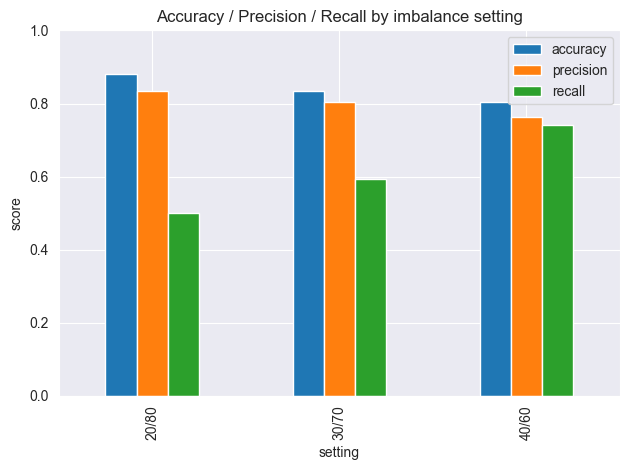

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt

def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }

results = []
for setting, (model, X_test, y_test) in models_dict.items():
    m = eval_model(model, X_test, y_test)
    m["setting"] = setting
    results.append(m)

res_df = pd.DataFrame(results).set_index("setting")
display(res_df)

res_df.plot(kind="bar")
plt.ylim(0, 1)
plt.title("Accuracy / Precision / Recall by imbalance setting")
plt.ylabel("score")
plt.tight_layout()
plt.show()

## 4. Report 
### Write a small report (few sentences) to discuss from your analysis, the impact of class imballance on logistic model's performance 

`Write your report here`

As class imbalance becomes more severe, the logistic regression model increasingly favors the majority class. This leads to very high recall for class 0 but poor recall for the minority class 1, meaning many true positives are missed. When the dataset becomes less imbalanced (e.g., 40/60), minority-class recall improves noticeably, while majority-class recall slightly decreases. Therefore, overall accuracy can be misleading under imbalance, and per-class recall (and precision/recall) should be used to judge performance.
